# Experiment 2.2 — Readout sanity check with one shared SNN backbone

## What this notebook now tests

This version fixes the main methodological problem in the previous notebook:

> **The three readouts no longer train three different SNNs.**

For each master seed, the notebook trains **one** feed-forward SNN backbone using one common, repo-style training objective. The trained backbone is then frozen and the same output spike train / membrane trajectory is read in three different ways.

This makes Experiment 2.2 much closer to its intended question:

\[
\boxed{\text{Does the readout itself discard useful temporal information?}}
\]

rather than:

\[
\text{Which of three different end-to-end training objectives works best?}
\]

---

## Shared backbone

The input channel count \(C\) is read dynamically from the unsigned event metadata.

\[
C \rightarrow 64 \rightarrow 64 \rightarrow K
\]

The backbone remains deliberately simple:

- feed-forward only;
- no recurrence;
- one fixed \(\tau_{syn}\);
- one fixed \(\tau_{mem}\);
- fixed threshold;
- no multi-\(\tau\);
- direct unsigned weighted events.

The current default physical dynamics remain:

- \(\tau_{syn}=77.47\) ms;
- \(\tau_{mem}=7.213\) ms;
- threshold \(=1.0\).

---

## Shared SNN training objective

The backbone is trained once per seed using the current GitHub Action0-style objective:

\[
L_{\text{backbone}}
=
\frac{1}{N_{\text{valid}}}
\sum_{b,t\in valid}
CE(s_{b,t}, y_b)
\]

That is, the segment label is repeated logically across valid timesteps, and the output spike vector at every valid timestep receives the same class supervision.

This is intentionally separate from the later readout comparison.

By default the best backbone epoch is selected by **validation full-count balanced accuracy**, matching the existing Action0 training logic. This slightly favors `full_count`; therefore a large later gain from a temporal readout is a conservative result. `BACKBONE_SELECTION_METRIC` can be changed to `"val_loss"` if a readout-neutral checkpoint criterion is preferred.

---

## Frozen-backbone readouts

After backbone training, the exact same frozen SNN outputs are used for all three readouts.

### A — `full_count`

\[
score_k=\sum_{t\in valid}s_k(t)
\]

No additional trainable parameters.

### B — `temporal_10bin`

The valid gesture is divided into ten equal-progress relative-time bins:

\[
z_{b,k}=\sum_{t\in bin_b}s_k(t)
\]

giving a \(10K\)-dimensional feature.

Only a small readout head is trained:

\[
Linear(10K \rightarrow K)
\]

**The SNN backbone stays frozen.**

### C — `final_membrane`

Use the output-layer membrane state at the last valid timestep:

\[
score_k=V_k(T_{\text{valid}}-1)
\]

No additional trainable parameters.

---

## Why this is faster

Previous notebook:

```text
N seeds × 3 readouts = 3N full SNN trainings
```

Fixed notebook:

```text
N seeds × 1 shared backbone = N full SNN trainings
+ tiny frozen-feature linear heads for 10-bin
```

So the expensive SNN training workload is reduced by roughly a factor of three.

---

## Firing-rate interpretation

Because all readouts now use the same backbone, `L1/L2/output firing rate` is a **backbone property** and is recorded once per seed/split.

If firing statistics appear different across readouts, that would now indicate a bug.

The notebook also includes a zero-input firing diagnostic to expose bias-driven tonic firing.


In [87]:
from __future__ import annotations

from pathlib import Path
import copy
import hashlib
import json
import math
import os
import random
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset
from IPython.display import display

try:
    import snntorch as snn
    from snntorch import surrogate
except ImportError as exc:
    raise ImportError(
        "Experiment 2.1 requires snntorch. From the repository root run: "
        "python -m pip install -e '.[snn,notebook]'"
    ) from exc

try:
    from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score
except ImportError as exc:
    raise ImportError(
        "Experiment 2.1 requires scikit-learn for classification metrics. "
        "Install it with: python -m pip install scikit-learn"
    ) from exc


def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "snn").is_dir() and (candidate / "notebooks").is_dir():
            return candidate
    raise FileNotFoundError(
        "Could not locate the writingRing repository root from the current working directory."
    )


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from snn.accel_reconstruction_eval.datasets import load_acceleration_data

print("Repository root:", REPO_ROOT)
print("PyTorch:", torch.__version__)
print("snntorch:", getattr(snn, "__version__", "unknown"))
print("CUDA available:", torch.cuda.is_available())


Repository root: /home/ted/project/writingring-viz
PyTorch: 2.11.0+cu130
snntorch: 0.9.4
CUDA available: True


## 1. Configuration

The dataset roots and current label subset are preserved from the uploaded notebook.

`SEEDS=(11,23)` is also preserved for quick iteration. Expand to five seeds only after the backbone firing regime and training curves look reasonable.


In [88]:
# -----------------------------------------------------------------------------
# USER CONFIGURATION
# -----------------------------------------------------------------------------

DATASET_ROOTS = [
    REPO_ROOT / "outputs/action0_wavelets_1_2_4_8_16",
    REPO_ROOT / "outputs/action1_wavelets_1_2_4_8_16",
]

SEEDS = (23, 11, 101, 40, 231) #

# One fixed user split is shared by every seed and every readout.
SPLIT_SEED: int = 12345

INCLUDED_LABELS = (
    "A", "B", "C", "D", "E", "X",
    "G", "H", "I", "J", "K", "L",
)

TRAIN_FRACTION = 0.70
VAL_FRACTION = 0.15

BATCH_SIZE = 64
NUM_WORKERS = 0

# Full SNN training.
NUM_EPOCHS = 50
EARLY_STOPPING_PATIENCE = 8
LEARNING_RATE = 5e-4
WEIGHT_DECAY = 0.0
SPIKE_REGULARIZATION = 0.0
GRAD_CLIP_NORM = None

# Match the existing Action0 model-selection convention by default.
# Allowed: "val_balanced_accuracy", "val_loss"
BACKBONE_SELECTION_METRIC = "val_loss"

# Tiny frozen-feature temporal readout head.
TEMPORAL_HEAD_EPOCHS = 200
TEMPORAL_HEAD_PATIENCE = 20
TEMPORAL_HEAD_LR = 1e-2
TEMPORAL_HEAD_WEIGHT_DECAY = 0.0

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Set from metadata after loading.
INPUT_CHANNELS: int | None = None

HIDDEN_WIDTH = 64
READOUTS = ("full_count", "temporal_10bin", "final_membrane")
N_TEMPORAL_BINS = 10

TAU_SYN_MS = 77.47
TAU_MEM_MS = 7.213
THRESHOLD = 1.0
SURROGATE_SLOPE = 25.0
RESET_MECHANISM = "subtract"

# Preserve the original 2.1 fixed-dynamics control.
LEARN_ALPHA = False
LEARN_BETA = False
LEARN_THRESHOLD = False
LINEAR_BIAS = False

ZERO_INPUT_DIAGNOSTIC_STEPS = 200

EXPERIMENT_ID = "experiment_2_1_fixed_shared_backbone"
EXPERIMENT_TITLE = "Experiment 2.1 — Shared-backbone SNN readout sanity check"
RESULTS_DIR = (
    REPO_ROOT
    / "notebooks/artifacts/experiment_2_1_snn_readout_sanity_check_fixed"
)

print("Dataset roots:")
for root in DATASET_ROOTS:
    print(" -", root)
print("Seeds:", SEEDS)
print("Split seed:", SPLIT_SEED)
print("Backbone selection:", BACKBONE_SELECTION_METRIC)
print("Readouts:", READOUTS)
print("Device:", DEVICE)


Dataset roots:
 - /home/ted/project/writingring-viz/outputs/action0_wavelets_1_2_4_8_16
 - /home/ted/project/writingring-viz/outputs/action1_wavelets_1_2_4_8_16
Seeds: (23, 11, 101, 40, 231)
Split seed: 12345
Backbone selection: val_loss
Readouts: ('full_count', 'temporal_10bin', 'final_membrane')
Device: cuda


## 2. Reproducibility helpers


In [89]:
def derive_seed(master_seed: int, *parts: object) -> int:
    text = "|".join([str(master_seed), *(str(p) for p in parts)])
    digest = hashlib.sha256(text.encode("utf-8")).digest()
    return int.from_bytes(digest[:4], "little", signed=False)


def seed_everything(seed: int) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

    try:
        torch.use_deterministic_algorithms(True, warn_only=True)
    except TypeError:
        torch.use_deterministic_algorithms(True)


def worker_init_fn(worker_id: int) -> None:
    worker_seed = torch.initial_seed() % (2**32)
    random.seed(worker_seed)
    np.random.seed(worker_seed)


## 3. Load and validate the unsigned dynamic-channel event cohort

The SNN input channel count is **not hard-coded**.

The loader requires:

- `event_representation == "unsigned"`;
- one shared `event_feature_schema`;
- one shared `event_channel_count`;
- one shared encoder specification;
- actual valid event values are non-negative.

Only the first `event_channel_count` channels are passed to the SNN. Auxiliary acceleration / gyro channels are not used by the classifier.


In [90]:
data = load_acceleration_data(
    DATASET_ROOTS,
    repository_root=REPO_ROOT,
    require_reconstruction=False,
)

sampling_rates = {float(m.sampling_rate_hz) for m in data.producer_metadatas}
if len(sampling_rates) != 1:
    raise ValueError(f"Expected one shared sampling rate, got {sampling_rates}")
SAMPLING_RATE_HZ = sampling_rates.pop()

event_contracts = set()

for metadata in data.producer_metadatas:
    raw = metadata.raw

    event_representation = raw.get("event_representation")
    event_feature_schema = raw.get("event_feature_schema")
    event_channel_count = raw.get("event_channel_count")
    encoder_spec_sha256 = raw.get("spike_encoder_spec_sha256")

    if event_representation != "unsigned":
        raise ValueError(
            "Experiment 2.1 requires event_representation='unsigned'; "
            f"got {event_representation!r}"
        )

    if not isinstance(event_feature_schema, str) or not event_feature_schema:
        raise ValueError("Missing event_feature_schema in padded SpikeIMU metadata")

    if not isinstance(event_channel_count, int) or event_channel_count <= 0:
        raise ValueError(
            f"event_channel_count must be a positive integer; got {event_channel_count!r}"
        )

    # Current SpikeIMU artifacts carry six auxiliary IMU channels after events.
    if event_channel_count != metadata.channel_count - 6:
        raise ValueError(
            "Current padded SpikeIMU contract expects six auxiliary IMU channels after events; "
            f"event_channel_count={event_channel_count}, total channel_count={metadata.channel_count}"
        )

    if not isinstance(encoder_spec_sha256, str) or len(encoder_spec_sha256) != 64:
        raise ValueError("Missing spike_encoder_spec_sha256 in padded SpikeIMU metadata")

    event_contracts.add(
        (
            event_representation,
            event_feature_schema,
            event_channel_count,
            encoder_spec_sha256,
        )
    )

if len(event_contracts) != 1:
    raise ValueError(
        "All selected roots must share event representation, feature schema, "
        "event channel count, and encoder spec; "
        f"got {event_contracts}"
    )

(
    EVENT_REPRESENTATION,
    EVENT_FEATURE_SCHEMA,
    INPUT_CHANNELS,
    ENCODER_SPEC_SHA256,
) = event_contracts.pop()

rows = []
included = None if INCLUDED_LABELS is None else set(map(str, INCLUDED_LABELS))

for package_index, package in enumerate(data.packages):
    for segment_index, label in enumerate(package.labels.astype(str)):
        label = str(label)

        if included is not None and label not in included:
            continue

        valid_length = int(package.valid_lengths[segment_index])

        if valid_length <= 0:
            raise ValueError(
                f"Non-positive valid_length for "
                f"{package.user}/action_{package.action}/{segment_index}"
            )

        event_values = np.asarray(
            package.padded_spike_imu[
                segment_index,
                :valid_length,
                :INPUT_CHANNELS,
            ]
        )

        if np.any(~np.isfinite(event_values)):
            raise ValueError(
                f"Non-finite event values in "
                f"{package.user}/action_{package.action}/{segment_index}"
            )

        if np.any(event_values < 0.0):
            raise ValueError(
                f"Unsigned event contract violated by negative event values in "
                f"{package.user}/action_{package.action}/{segment_index}"
            )

        rows.append(
            {
                "package_index": package_index,
                "segment_index": segment_index,
                "user": str(package.user),
                "action": str(package.action),
                "label": label,
                "valid_length": valid_length,
                "sample_id": (
                    f"{package.user}/action_{package.action}/{segment_index}"
                ),
            }
        )

manifest = pd.DataFrame(rows)

if manifest.empty:
    raise ValueError("No samples remain after applying INCLUDED_LABELS")

labels_sorted = sorted(manifest["label"].unique().tolist())
CLASS_TO_IDX = {label: i for i, label in enumerate(labels_sorted)}
IDX_TO_CLASS = {i: label for label, i in CLASS_TO_IDX.items()}
manifest["label_idx"] = manifest["label"].map(CLASS_TO_IDX).astype(int)

NUM_CLASSES = len(CLASS_TO_IDX)

dt_ms = 1000.0 / SAMPLING_RATE_HZ
ALPHA = float(math.exp(-dt_ms / TAU_SYN_MS))
BETA = float(math.exp(-dt_ms / TAU_MEM_MS))

if not (0.0 < ALPHA < 1.0 and 0.0 < BETA < 1.0):
    raise ValueError(f"Invalid decay values alpha={ALPHA}, beta={BETA}")

print(f"Loaded {len(manifest):,} samples from {manifest['user'].nunique()} users")
print("Actions:", sorted(manifest["action"].unique().tolist()))
print("Classes:", NUM_CLASSES, labels_sorted)
print("Sampling rate:", SAMPLING_RATE_HZ, "Hz")
print("Event representation:", EVENT_REPRESENTATION)
print("Event feature schema:", EVENT_FEATURE_SCHEMA)
print("SNN input channels:", INPUT_CHANNELS)
print("dt:", dt_ms, "ms")
print(f"tau_syn={TAU_SYN_MS:.3f} ms -> alpha={ALPHA:.6f}")
print(f"tau_mem={TAU_MEM_MS:.3f} ms -> beta={BETA:.6f}")
print("Threshold:", THRESHOLD)
print(
    "Valid-length range:",
    manifest["valid_length"].min(),
    "..",
    manifest["valid_length"].max(),
)
display(manifest.head())


Loaded 911 samples from 20 users
Actions: ['0', '1']
Classes: 12 ['A', 'B', 'C', 'D', 'E', 'G', 'H', 'I', 'J', 'K', 'L', 'X']
Sampling rate: 200.0 Hz
Event representation: unsigned
Event feature schema: custom_wavelet_polarity_split_abs_events_v1
SNN input channels: 30
dt: 5.0 ms
tau_syn=77.470 ms -> alpha=0.937498
tau_mem=7.213 ms -> beta=0.499977
Threshold: 1.0
Valid-length range: 133 .. 600


,package_index,segment_index,user,action,label,valid_length,sample_id,label_idx
0,0,24,user_0,0,J,225,user_0/action_0/24,8
1,0,25,user_0,0,B,405,user_0/action_0/25,1
2,0,26,user_0,0,X,335,user_0/action_0/26,11
3,0,27,user_0,0,E,384,user_0/action_0/27,4
4,0,31,user_0,0,G,388,user_0/action_0/31,5


## 4. One fixed user-disjoint split

The user split is generated once from `SPLIT_SEED` and reused for every model seed.


In [91]:
def make_user_split(manifest: pd.DataFrame) -> pd.DataFrame:
    users = sorted(manifest["user"].unique().tolist())

    if len(users) < 3:
        raise ValueError(
            "Need at least 3 users for user-disjoint train/val/test splitting"
        )

    rng = np.random.default_rng(SPLIT_SEED)
    perm = np.array(users, dtype=object)
    rng.shuffle(perm)

    n = len(perm)
    n_train = max(1, int(np.floor(TRAIN_FRACTION * n)))
    n_val = max(1, int(np.floor(VAL_FRACTION * n)))

    if n_train + n_val >= n:
        n_train = n - 2
        n_val = 1

    train_users = set(perm[:n_train].tolist())
    val_users = set(perm[n_train:n_train + n_val].tolist())
    test_users = set(perm[n_train + n_val:].tolist())

    out = manifest.copy()

    out["split"] = out["user"].map(
        lambda u: (
            "train"
            if u in train_users
            else ("val" if u in val_users else "test")
        )
    )

    train_set = set(out.loc[out.split == "train", "user"])
    val_set = set(out.loc[out.split == "val", "user"])
    test_set = set(out.loc[out.split == "test", "user"])

    assert train_set.isdisjoint(val_set)
    assert train_set.isdisjoint(test_set)
    assert val_set.isdisjoint(test_set)

    return out


FIXED_SPLIT_MANIFEST = make_user_split(manifest)

split_review = []

for split in ("train", "val", "test"):
    part = FIXED_SPLIT_MANIFEST[
        FIXED_SPLIT_MANIFEST.split == split
    ]

    split_review.append(
        {
            "split": split,
            "users": part.user.nunique(),
            "samples": len(part),
            "classes_present": part.label.nunique(),
            "user_names": ", ".join(sorted(part.user.unique())),
        }
    )

split_review = pd.DataFrame(split_review)
display(split_review)

if (split_review["classes_present"] < NUM_CLASSES).any():
    print(
        "WARNING: at least one split does not contain every selected class. "
        "Inspect the split before interpreting balanced accuracy."
    )


,split,users,samples,classes_present,user_names
0,train,14,619,12,"user_0, user_1, user_11, user_12, user_13, use..."
1,val,3,125,12,"user_16, user_4, user_9"
2,test,3,167,12,"user_10, user_3, user_6"


## 5. Dataset adapter and deterministic DataLoaders

The direct weighted-event amplitudes are preserved. No normalization and no binarization are applied.


In [92]:
class EventSNNDataset(Dataset):
    def __init__(self, data, split_manifest: pd.DataFrame):
        self.data = data
        self.df = split_manifest.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        row = self.df.iloc[index]
        package = self.data.packages[int(row.package_index)]
        segment_index = int(row.segment_index)
        valid_length = int(row.valid_length)

        x = np.asarray(
            package.padded_spike_imu[
                segment_index,
                :,
                :INPUT_CHANNELS,
            ],
            dtype=np.float32,
        ).copy()

        if x.shape[1] != INPUT_CHANNELS:
            raise ValueError(
                f"Expected {INPUT_CHANNELS} event channels, got {x.shape[1]} "
                f"for {row.sample_id}"
            )

        if np.any(x[:valid_length] < 0.0):
            raise ValueError(
                f"Unsigned event contract violated for {row.sample_id}"
            )

        # Explicitly enforce right-padding semantics.
        x[valid_length:] = 0.0
        valid_mask = np.arange(x.shape[0]) < valid_length

        return {
            "x": torch.from_numpy(x),
            "label": torch.tensor(
                int(row.label_idx),
                dtype=torch.long,
            ),
            "valid_mask": torch.from_numpy(valid_mask),
            "valid_length": torch.tensor(
                valid_length,
                dtype=torch.long,
            ),
            "sample_id": str(row.sample_id),
        }


def make_loaders(
    data,
    split_manifest: pd.DataFrame,
    master_seed: int,
):
    subsets = {
        "train": split_manifest[split_manifest.split == "train"],
        "train_eval": split_manifest[split_manifest.split == "train"],
        "val": split_manifest[split_manifest.split == "val"],
        "test": split_manifest[split_manifest.split == "test"],
    }

    loaders = {}

    for name, df in subsets.items():
        dataset = EventSNNDataset(data, df)

        generator = torch.Generator().manual_seed(
            derive_seed(master_seed, name, "loader")
        )

        loaders[name] = DataLoader(
            dataset,
            batch_size=BATCH_SIZE,
            shuffle=(name == "train"),
            num_workers=NUM_WORKERS,
            generator=generator,
            worker_init_fn=(
                worker_init_fn
                if NUM_WORKERS > 0
                else None
            ),
            pin_memory=torch.cuda.is_available(),
        )

    return loaders


## 6. Relative-time 10-bin helper

For valid length \(L\), valid timestep \(t\) is assigned to:

\[
b(t)=\left\lfloor \frac{10t}{L}\right\rfloor
\]

so all ten bins describe relative gesture progress rather than absolute padded time.


In [93]:
def relative_temporal_bin_counts(
    output_spikes: torch.Tensor,
    valid_lengths: torch.Tensor,
    n_bins: int,
) -> torch.Tensor:
    if output_spikes.ndim != 3:
        raise ValueError(
            f"Expected [B,T,K] output spikes, got {tuple(output_spikes.shape)}"
        )

    if n_bins <= 0:
        raise ValueError("n_bins must be positive")

    _, time_steps, _ = output_spikes.shape

    lengths = valid_lengths.to(
        device=output_spikes.device,
        dtype=torch.long,
    )

    if (lengths <= 0).any():
        raise ValueError("All valid lengths must be positive")

    if (lengths > time_steps).any():
        raise ValueError(
            "A valid length exceeds the padded sequence length"
        )

    if (lengths < n_bins).any():
        raise ValueError(
            f"n_bins={n_bins} exceeds at least one valid length; "
            f"minimum valid length is {int(lengths.min().item())}"
        )

    t = torch.arange(
        time_steps,
        device=output_spikes.device,
    )[None, :]

    valid = t < lengths[:, None]

    bin_index = torch.div(
        t * n_bins,
        lengths[:, None],
        rounding_mode="floor",
    ).clamp_max(n_bins - 1)

    one_hot = F.one_hot(
        bin_index,
        num_classes=n_bins,
    ).to(output_spikes.dtype)

    one_hot = (
        one_hot
        * valid.unsqueeze(-1).to(output_spikes.dtype)
    )

    return torch.einsum(
        "btn,btk->bnk",
        one_hot,
        output_spikes,
    )


## 7. Shared fixed-dynamics SNN backbone

There is no readout-specific branch inside this model.

The model always returns:

- hidden layer 1 spikes;
- hidden layer 2 spikes;
- output spikes;
- output membrane trajectory.

The exact same tensors are later consumed by every readout.


In [94]:
class SharedBackboneSNN(nn.Module):
    def __init__(
        self,
        num_classes: int,
        *,
        input_channels: int,
        hidden_width: int = HIDDEN_WIDTH,
        alpha: float = ALPHA,
        beta: float = BETA,
        threshold: float = THRESHOLD,
    ):
        super().__init__()

        self.num_classes = int(num_classes)
        self.input_channels = int(input_channels)
        self.hidden_width = int(hidden_width)

        spike_grad = surrogate.fast_sigmoid(
            slope=SURROGATE_SLOPE
        )

        self.fc1 = nn.Linear(
            self.input_channels,
            hidden_width,
            bias=LINEAR_BIAS,
        )

        self.lif1 = snn.Synaptic(
            alpha=alpha,
            beta=beta,
            threshold=threshold,
            spike_grad=spike_grad,
            learn_alpha=LEARN_ALPHA,
            learn_beta=LEARN_BETA,
            learn_threshold=LEARN_THRESHOLD,
            reset_mechanism=RESET_MECHANISM,
        )

        self.fc2 = nn.Linear(
            hidden_width,
            hidden_width,
            bias=LINEAR_BIAS,
        )

        self.lif2 = snn.Synaptic(
            alpha=alpha,
            beta=beta,
            threshold=threshold,
            spike_grad=spike_grad,
            learn_alpha=LEARN_ALPHA,
            learn_beta=LEARN_BETA,
            learn_threshold=LEARN_THRESHOLD,
            reset_mechanism=RESET_MECHANISM,
        )

        self.fc_out = nn.Linear(
            hidden_width,
            num_classes,
            bias=LINEAR_BIAS,
        )

        self.lif_out = snn.Synaptic(
            alpha=alpha,
            beta=beta,
            threshold=threshold,
            spike_grad=spike_grad,
            learn_alpha=LEARN_ALPHA,
            learn_beta=LEARN_BETA,
            learn_threshold=LEARN_THRESHOLD,
            reset_mechanism=RESET_MECHANISM,
        )

    @property
    def backbone_parameter_count(self) -> int:
        return sum(
            p.numel()
            for p in self.parameters()
        )

    @property
    def spike_neuron_count(self) -> int:
        return (
            2 * self.hidden_width
            + self.num_classes
        )

    def forward(
        self,
        x: torch.Tensor,
        valid_mask: torch.Tensor,
    ):
        if x.ndim != 3 or x.shape[-1] != self.input_channels:
            raise ValueError(
                f"x must have shape [B,T,{self.input_channels}], "
                f"got {tuple(x.shape)}"
            )

        if valid_mask.shape != x.shape[:2]:
            raise ValueError(
                f"valid_mask must have shape {tuple(x.shape[:2])}, "
                f"got {tuple(valid_mask.shape)}"
            )

        self.lif1.reset_mem()
        self.lif2.reset_mem()
        self.lif_out.reset_mem()

        spk1_rec = []
        spk2_rec = []
        spk_out_rec = []
        mem_out_rec = []

        for step in range(x.shape[1]):
            spk1, _, _ = self.lif1(
                self.fc1(x[:, step, :])
            )

            spk2, _, _ = self.lif2(
                self.fc2(spk1)
            )

            spk_out, _, mem_out = self.lif_out(
                self.fc_out(spk2)
            )

            spk1_rec.append(spk1)
            spk2_rec.append(spk2)
            spk_out_rec.append(spk_out)
            mem_out_rec.append(mem_out)

        spk1_rec = torch.stack(spk1_rec, dim=1)
        spk2_rec = torch.stack(spk2_rec, dim=1)
        spk_out_rec = torch.stack(spk_out_rec, dim=1)
        mem_out_rec = torch.stack(mem_out_rec, dim=1)

        mask_f = valid_mask.unsqueeze(-1).to(
            dtype=spk_out_rec.dtype
        )

        total_valid_spikes = (
            (spk1_rec * mask_f).sum()
            + (spk2_rec * mask_f).sum()
            + (spk_out_rec * mask_f).sum()
        )

        return {
            "spk1": spk1_rec,
            "spk2": spk2_rec,
            "output_spikes": spk_out_rec,
            "output_membrane": mem_out_rec,
            "total_valid_spikes": total_valid_spikes,
        }


seed_everything(
    derive_seed(SEEDS[0], "model_init")
)

_model_preview = SharedBackboneSNN(
    NUM_CLASSES,
    input_channels=INPUT_CHANNELS,
)

print(
    "Shared backbone params:",
    f"{_model_preview.backbone_parameter_count:,}",
)
print(
    "Architecture:",
    f"{INPUT_CHANNELS} -> {HIDDEN_WIDTH} -> "
    f"{HIDDEN_WIDTH} -> {NUM_CLASSES}",
)

del _model_preview


Shared backbone params: 6,784
Architecture: 30 -> 64 -> 64 -> 12


## 8. Repo-style masked per-timestep training loss

This matches the key training-objective logic in `snn/action0_losses.py`:

- the segment label is logically repeated across valid timesteps;
- cross entropy is computed for every valid timestep;
- invalid right-padding positions contribute zero loss.

Optional spike regularization is preserved as a configuration parameter and defaults to zero.


In [95]:
def masked_timestep_loss(
    output_spikes: torch.Tensor,
    labels: torch.Tensor,
    valid_mask: torch.Tensor,
    *,
    total_valid_spikes: torch.Tensor | None = None,
    spike_neuron_count: int | None = None,
) -> torch.Tensor:
    if output_spikes.ndim != 3:
        raise ValueError(
            "output_spikes must have shape [B,T,K]"
        )

    batch_size, time_steps, class_count = (
        output_spikes.shape
    )

    if labels.shape != (batch_size,):
        raise ValueError(
            f"labels must have shape {(batch_size,)}, "
            f"got {tuple(labels.shape)}"
        )

    if valid_mask.shape != (batch_size, time_steps):
        raise ValueError(
            "valid_mask shape does not match output_spikes"
        )

    targets = labels[:, None].expand(
        batch_size,
        time_steps,
    )

    loss_per_step = F.cross_entropy(
        output_spikes.reshape(
            batch_size * time_steps,
            class_count,
        ),
        targets.reshape(
            batch_size * time_steps
        ),
        reduction="none",
    ).reshape(
        batch_size,
        time_steps,
    )

    mask_f = valid_mask.to(
        device=loss_per_step.device,
        dtype=loss_per_step.dtype,
    )

    classification_loss = (
        (loss_per_step * mask_f).sum()
        / mask_f.sum().clamp_min(1)
    )

    if SPIKE_REGULARIZATION == 0.0:
        return classification_loss

    if total_valid_spikes is None:
        raise ValueError(
            "total_valid_spikes is required when "
            "SPIKE_REGULARIZATION > 0"
        )

    if (
        spike_neuron_count is None
        or spike_neuron_count <= 0
    ):
        raise ValueError(
            "spike_neuron_count must be positive"
        )

    valid_neuron_time = (
        mask_f.sum().clamp_min(1)
        * spike_neuron_count
    )

    return (
        classification_loss
        + SPIKE_REGULARIZATION
        * total_valid_spikes
        / valid_neuron_time
    )


## 9. Backbone metrics and firing diagnostics

Backbone classification during training follows the existing Action0 convention:

\[
\hat y = rg\max_k \sum_{t\in valid}s_k(t)
\]

This metric is used only to train/select the shared backbone; it is **not** a separate SNN for the `full_count` readout.


In [96]:
def classification_metrics(
    y_true,
    y_pred,
):
    return {
        "accuracy": float(
            accuracy_score(
                y_true,
                y_pred,
            )
        ),
        "balanced_accuracy": float(
            balanced_accuracy_score(
                y_true,
                y_pred,
            )
        ),
        "macro_f1": float(
            f1_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            )
        ),
    }


def _activity_from_totals(
    *,
    total_valid_steps: int,
    total_samples: int,
    l1_spikes: float,
    l2_spikes: float,
    output_spikes: float,
    silent_output_samples: int,
):
    return {
        "l1_firing_rate": (
            l1_spikes
            / max(
                total_valid_steps * HIDDEN_WIDTH,
                1,
            )
        ),
        "l2_firing_rate": (
            l2_spikes
            / max(
                total_valid_steps * HIDDEN_WIDTH,
                1,
            )
        ),
        "output_firing_rate": (
            output_spikes
            / max(
                total_valid_steps * NUM_CLASSES,
                1,
            )
        ),
        "network_firing_rate": (
            (
                l1_spikes
                + l2_spikes
                + output_spikes
            )
            / max(
                total_valid_steps
                * (
                    2 * HIDDEN_WIDTH
                    + NUM_CLASSES
                ),
                1,
            )
        ),
        "silent_output_fraction": (
            silent_output_samples
            / max(total_samples, 1)
        ),
    }


@torch.no_grad()
def evaluate_backbone(
    model,
    loader,
):
    model.eval()

    y_true = []
    y_pred = []

    total_loss_weighted = 0.0
    total_valid_steps = 0
    total_samples = 0

    l1_spikes = 0.0
    l2_spikes = 0.0
    output_spikes = 0.0
    silent_output_samples = 0

    for batch in loader:
        x = batch["x"].to(
            DEVICE,
            non_blocking=True,
        )
        y = batch["label"].to(
            DEVICE,
            non_blocking=True,
        )
        mask = batch["valid_mask"].to(
            DEVICE,
            non_blocking=True,
        )

        out = model(
            x,
            mask,
        )

        loss = masked_timestep_loss(
            out["output_spikes"],
            y,
            mask,
            total_valid_spikes=out[
                "total_valid_spikes"
            ],
            spike_neuron_count=(
                model.spike_neuron_count
            ),
        )

        mask_f = mask.unsqueeze(-1).to(
            out["output_spikes"].dtype
        )

        counts = (
            out["output_spikes"]
            * mask_f
        ).sum(dim=1)

        pred = counts.argmax(dim=1)

        y_true.extend(
            y.detach().cpu().tolist()
        )
        y_pred.extend(
            pred.detach().cpu().tolist()
        )

        batch_valid_steps = int(
            mask.sum().item()
        )
        batch_size = len(y)

        total_loss_weighted += (
            float(loss.item())
            * batch_valid_steps
        )
        total_valid_steps += (
            batch_valid_steps
        )
        total_samples += batch_size

        batch_l1 = (
            out["spk1"]
            * mask_f
        ).sum(dim=(1, 2))

        batch_l2 = (
            out["spk2"]
            * mask_f
        ).sum(dim=(1, 2))

        batch_out = (
            out["output_spikes"]
            * mask_f
        ).sum(dim=(1, 2))

        l1_spikes += float(
            batch_l1.sum().item()
        )
        l2_spikes += float(
            batch_l2.sum().item()
        )
        output_spikes += float(
            batch_out.sum().item()
        )

        silent_output_samples += int(
            (batch_out == 0).sum().item()
        )

    metrics = classification_metrics(
        y_true,
        y_pred,
    )

    metrics["loss"] = (
        total_loss_weighted
        / max(total_valid_steps, 1)
    )

    metrics.update(
        _activity_from_totals(
            total_valid_steps=total_valid_steps,
            total_samples=total_samples,
            l1_spikes=l1_spikes,
            l2_spikes=l2_spikes,
            output_spikes=output_spikes,
            silent_output_samples=(
                silent_output_samples
            ),
        )
    )

    metrics["samples"] = total_samples

    return metrics


## 10. Train one backbone per seed

This is the expensive part of the experiment.

The previous notebook trained it three times per seed. This notebook trains it **once**.


In [97]:
def fit_backbone(
    model: nn.Module,
    train_loader,
    val_loader,
):
    model = model.to(DEVICE)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    best_state = None
    best_epoch = -1
    best_selection_value = None
    no_improvement = 0
    history = []

    for epoch in range(
        1,
        NUM_EPOCHS + 1,
    ):
        model.train()

        running_loss_weighted = 0.0
        running_valid_steps = 0

        train_y_true = []
        train_y_pred = []

        for batch in train_loader:
            x = batch["x"].to(
                DEVICE,
                non_blocking=True,
            )
            y = batch["label"].to(
                DEVICE,
                non_blocking=True,
            )
            mask = batch["valid_mask"].to(
                DEVICE,
                non_blocking=True,
            )

            optimizer.zero_grad(
                set_to_none=True
            )

            out = model(
                x,
                mask,
            )

            loss = masked_timestep_loss(
                out["output_spikes"],
                y,
                mask,
                total_valid_spikes=out[
                    "total_valid_spikes"
                ],
                spike_neuron_count=(
                    model.spike_neuron_count
                ),
            )

            if not torch.isfinite(loss):
                raise FloatingPointError(
                    "Non-finite backbone training loss"
                )

            loss.backward()

            if GRAD_CLIP_NORM is not None:
                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    GRAD_CLIP_NORM,
                )

            optimizer.step()

            batch_valid_steps = int(
                mask.sum().item()
            )

            running_loss_weighted += (
                float(loss.item())
                * batch_valid_steps
            )
            running_valid_steps += (
                batch_valid_steps
            )

            with torch.no_grad():
                mask_f = (
                    mask.unsqueeze(-1)
                    .to(
                        out[
                            "output_spikes"
                        ].dtype
                    )
                )

                counts = (
                    out["output_spikes"]
                    * mask_f
                ).sum(dim=1)

                pred = counts.argmax(
                    dim=1
                )

                train_y_true.extend(
                    y.detach().cpu().tolist()
                )
                train_y_pred.extend(
                    pred.detach().cpu().tolist()
                )

        train_metrics = (
            classification_metrics(
                train_y_true,
                train_y_pred,
            )
        )

        train_loss = (
            running_loss_weighted
            / max(
                running_valid_steps,
                1,
            )
        )

        val_metrics = evaluate_backbone(
            model,
            val_loader,
        )

        history.append(
            {
                "epoch": epoch,
                "train_loss": train_loss,
                "train_accuracy": train_metrics[
                    "accuracy"
                ],
                "train_balanced_accuracy": train_metrics[
                    "balanced_accuracy"
                ],
                "train_macro_f1": train_metrics[
                    "macro_f1"
                ],
                "val_loss": val_metrics[
                    "loss"
                ],
                "val_accuracy": val_metrics[
                    "accuracy"
                ],
                "val_balanced_accuracy": val_metrics[
                    "balanced_accuracy"
                ],
                "val_macro_f1": val_metrics[
                    "macro_f1"
                ],
                "val_l1_firing_rate": val_metrics[
                    "l1_firing_rate"
                ],
                "val_l2_firing_rate": val_metrics[
                    "l2_firing_rate"
                ],
                "val_output_firing_rate": val_metrics[
                    "output_firing_rate"
                ],
                "val_silent_output_fraction": val_metrics[
                    "silent_output_fraction"
                ],
            }
        )

        if BACKBONE_SELECTION_METRIC == "val_balanced_accuracy":
            selection_value = val_metrics[
                "balanced_accuracy"
            ]
            improved = (
                best_selection_value is None
                or selection_value
                > best_selection_value + 1e-12
            )

        elif BACKBONE_SELECTION_METRIC == "val_loss":
            selection_value = val_metrics[
                "loss"
            ]
            improved = (
                best_selection_value is None
                or selection_value
                < best_selection_value - 1e-12
            )

        else:
            raise ValueError(
                "BACKBONE_SELECTION_METRIC must be "
                "'val_balanced_accuracy' or 'val_loss'"
            )

        if improved:
            best_selection_value = (
                selection_value
            )
            best_epoch = epoch
            best_state = copy.deepcopy(
                model.state_dict()
            )
            no_improvement = 0
        else:
            no_improvement += 1

        print(
            f"epoch {epoch:>3d} | "
            f"train loss={train_loss:.4f} "
            f"train BA={train_metrics['balanced_accuracy']:.4f} | "
            f"val loss={val_metrics['loss']:.4f} "
            f"val BA={val_metrics['balanced_accuracy']:.4f} | "
            f"out FR={val_metrics['output_firing_rate']:.4f}"
        )

        if (
            EARLY_STOPPING_PATIENCE
            is not None
            and no_improvement
            >= EARLY_STOPPING_PATIENCE
        ):
            break

    if best_state is None:
        raise RuntimeError(
            "Backbone training did not produce a best state"
        )

    model.load_state_dict(
        best_state
    )

    return (
        model,
        pd.DataFrame(history),
        best_epoch,
        best_selection_value,
    )


## 11. Freeze the backbone and extract all readout features once

After this point the SNN weights do not change.

For each sample we cache:

- full output spike counts: `[K]`;
- 10-bin output spike counts: `[10K]`;
- final valid output membrane: `[K]`;
- label.

This makes the later readout comparison cheap.


In [98]:
@torch.no_grad()
def extract_frozen_features(
    model,
    loader,
):
    model.eval()

    full_count_features = []
    temporal_features = []
    final_membrane_features = []
    labels = []

    total_valid_steps = 0
    total_samples = 0

    l1_spikes = 0.0
    l2_spikes = 0.0
    output_spikes = 0.0
    silent_output_samples = 0

    for batch in loader:
        x = batch["x"].to(
            DEVICE,
            non_blocking=True,
        )
        y = batch["label"].to(
            DEVICE,
            non_blocking=True,
        )
        mask = batch["valid_mask"].to(
            DEVICE,
            non_blocking=True,
        )
        lengths = batch[
            "valid_length"
        ].to(
            DEVICE,
            non_blocking=True,
        )

        out = model(
            x,
            mask,
        )

        mask_f = mask.unsqueeze(-1).to(
            out["output_spikes"].dtype
        )

        valid_output_spikes = (
            out["output_spikes"]
            * mask_f
        )

        full_counts = (
            valid_output_spikes.sum(
                dim=1
            )
        )

        bins = (
            relative_temporal_bin_counts(
                out["output_spikes"],
                lengths,
                N_TEMPORAL_BINS,
            )
        )

        gather_index = (
            (lengths - 1)
            .clamp_min(0)
            .view(-1, 1, 1)
            .expand(
                -1,
                1,
                NUM_CLASSES,
            )
        )

        final_mem = (
            out["output_membrane"]
            .gather(
                dim=1,
                index=gather_index,
            )
            .squeeze(1)
        )

        full_count_features.append(
            full_counts.cpu()
        )
        temporal_features.append(
            bins.flatten(
                start_dim=1
            ).cpu()
        )
        final_membrane_features.append(
            final_mem.cpu()
        )
        labels.append(
            y.cpu()
        )

        batch_valid_steps = int(
            mask.sum().item()
        )
        batch_size = len(y)

        total_valid_steps += (
            batch_valid_steps
        )
        total_samples += batch_size

        batch_l1 = (
            out["spk1"]
            * mask_f
        ).sum(dim=(1, 2))

        batch_l2 = (
            out["spk2"]
            * mask_f
        ).sum(dim=(1, 2))

        batch_out = (
            out["output_spikes"]
            * mask_f
        ).sum(dim=(1, 2))

        l1_spikes += float(
            batch_l1.sum().item()
        )
        l2_spikes += float(
            batch_l2.sum().item()
        )
        output_spikes += float(
            batch_out.sum().item()
        )

        silent_output_samples += int(
            (batch_out == 0).sum().item()
        )

    pack = {
        "full_count": torch.cat(
            full_count_features,
            dim=0,
        ),
        "temporal_10bin": torch.cat(
            temporal_features,
            dim=0,
        ),
        "final_membrane": torch.cat(
            final_membrane_features,
            dim=0,
        ),
        "labels": torch.cat(
            labels,
            dim=0,
        ),
    }

    activity = _activity_from_totals(
        total_valid_steps=total_valid_steps,
        total_samples=total_samples,
        l1_spikes=l1_spikes,
        l2_spikes=l2_spikes,
        output_spikes=output_spikes,
        silent_output_samples=(
            silent_output_samples
        ),
    )

    activity["samples"] = (
        total_samples
    )

    return pack, activity


## 12. Train only the frozen-feature 10-bin linear head

`full_count` and `final_membrane` have no trainable readout parameters.

Only `temporal_10bin` fits a `Linear(10K -> K)` classifier, and this optimization never touches the SNN.


In [99]:
def _tensor_classification_metrics(
    logits: torch.Tensor,
    labels: torch.Tensor,
):
    pred = logits.argmax(
        dim=1
    )

    return classification_metrics(
        labels.cpu().tolist(),
        pred.cpu().tolist(),
    )


@torch.no_grad()
def evaluate_linear_head(
    head,
    features: torch.Tensor,
    labels: torch.Tensor,
):
    head.eval()

    x = features.to(
        DEVICE,
    )
    y = labels.to(
        DEVICE,
    )

    logits = head(x)

    metrics = (
        _tensor_classification_metrics(
            logits,
            y,
        )
    )

    metrics["loss"] = float(
        F.cross_entropy(
            logits,
            y,
        ).item()
    )

    return metrics


def fit_temporal_head(
    *,
    master_seed: int,
    train_features: torch.Tensor,
    train_labels: torch.Tensor,
    val_features: torch.Tensor,
    val_labels: torch.Tensor,
):
    seed_everything(
        derive_seed(
            master_seed,
            "temporal_readout_head",
        )
    )

    head = nn.Linear(
        N_TEMPORAL_BINS
        * NUM_CLASSES,
        NUM_CLASSES,
    ).to(DEVICE)

    optimizer = torch.optim.Adam(
        head.parameters(),
        lr=TEMPORAL_HEAD_LR,
        weight_decay=(
            TEMPORAL_HEAD_WEIGHT_DECAY
        ),
    )

    dataset = TensorDataset(
        train_features.float(),
        train_labels.long(),
    )

    generator = (
        torch.Generator()
        .manual_seed(
            derive_seed(
                master_seed,
                "temporal_head_loader",
            )
        )
    )

    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=generator,
    )

    best_state = None
    best_val_ba = -np.inf
    best_epoch = -1
    no_improvement = 0
    history = []

    for epoch in range(
        1,
        TEMPORAL_HEAD_EPOCHS + 1,
    ):
        head.train()

        running_loss = 0.0
        sample_count = 0

        for xb, yb in loader:
            xb = xb.to(
                DEVICE
            )
            yb = yb.to(
                DEVICE
            )

            optimizer.zero_grad(
                set_to_none=True
            )

            logits = head(xb)

            loss = F.cross_entropy(
                logits,
                yb,
            )

            loss.backward()
            optimizer.step()

            running_loss += (
                float(loss.item())
                * len(yb)
            )
            sample_count += len(yb)

        val_metrics = evaluate_linear_head(
            head,
            val_features,
            val_labels,
        )

        history.append(
            {
                "epoch": epoch,
                "train_loss": (
                    running_loss
                    / max(
                        sample_count,
                        1,
                    )
                ),
                "val_loss": (
                    val_metrics[
                        "loss"
                    ]
                ),
                "val_accuracy": (
                    val_metrics[
                        "accuracy"
                    ]
                ),
                "val_balanced_accuracy": (
                    val_metrics[
                        "balanced_accuracy"
                    ]
                ),
                "val_macro_f1": (
                    val_metrics[
                        "macro_f1"
                    ]
                ),
            }
        )

        current = val_metrics[
            "balanced_accuracy"
        ]

        if current > best_val_ba + 1e-12:
            best_val_ba = current
            best_epoch = epoch
            best_state = copy.deepcopy(
                head.state_dict()
            )
            no_improvement = 0
        else:
            no_improvement += 1

        if (
            no_improvement
            >= TEMPORAL_HEAD_PATIENCE
        ):
            break

    if best_state is None:
        raise RuntimeError(
            "Temporal head training did not produce a best state"
        )

    head.load_state_dict(
        best_state
    )

    return (
        head,
        pd.DataFrame(history),
        best_epoch,
        best_val_ba,
    )


## 13. Readout evaluation helpers


In [100]:
def evaluate_direct_readout(
    features: torch.Tensor,
    labels: torch.Tensor,
):
    logits = features.float()
    y = labels.long()

    metrics = (
        _tensor_classification_metrics(
            logits,
            y,
        )
    )

    metrics["loss"] = float(
        F.cross_entropy(
            logits,
            y,
        ).item()
    )

    return metrics


def readout_parameter_count(
    readout: str,
):
    if readout == "temporal_10bin":
        return (
            N_TEMPORAL_BINS
            * NUM_CLASSES
            * NUM_CLASSES
            + NUM_CLASSES
        )

    return 0


## 14. Zero-input firing diagnostic

This diagnostic helps detect bias-driven tonic firing.

It does not change the model. It simply feeds an all-zero sequence through the trained backbone and reports per-layer firing rates.


In [101]:
@torch.no_grad()
def zero_input_activity(
    model,
    steps: int = ZERO_INPUT_DIAGNOSTIC_STEPS,
):
    model.eval()

    x = torch.zeros(
        1,
        steps,
        INPUT_CHANNELS,
        device=DEVICE,
    )

    mask = torch.ones(
        1,
        steps,
        dtype=torch.bool,
        device=DEVICE,
    )

    out = model(
        x,
        mask,
    )

    return {
        "zero_l1_firing_rate": float(
            out["spk1"].mean().item()
        ),
        "zero_l2_firing_rate": float(
            out["spk2"].mean().item()
        ),
        "zero_output_firing_rate": float(
            out[
                "output_spikes"
            ].mean().item()
        ),
    }


## 15. Main experiment — one SNN training per seed

For every master seed:

1. train one shared SNN backbone;
2. restore its best validation checkpoint;
3. freeze it;
4. extract train/val/test features once;
5. evaluate `full_count`;
6. train only the tiny 10-bin linear head on frozen train features;
7. evaluate `temporal_10bin`;
8. evaluate `final_membrane`;
9. record one set of backbone firing diagnostics.


In [102]:
RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

result_rows = []
backbone_history_rows = []
temporal_head_history_rows = []
activity_rows = []
zero_input_rows = []

for master_seed in SEEDS:
    print("=" * 100)
    print("MASTER SEED:", master_seed)

    loaders = make_loaders(
        data,
        FIXED_SPLIT_MANIFEST,
        master_seed,
    )

    seed_everything(
        derive_seed(
            master_seed,
            "model_init",
        )
    )

    model = SharedBackboneSNN(
        num_classes=NUM_CLASSES,
        input_channels=INPUT_CHANNELS,
    )

    print(
        "Training shared backbone once..."
    )

    (
        model,
        backbone_history,
        backbone_best_epoch,
        backbone_best_selection_value,
    ) = fit_backbone(
        model,
        loaders["train"],
        loaders["val"],
    )

    backbone_history.insert(
        0,
        "seed",
        master_seed,
    )
    backbone_history_rows.append(
        backbone_history
    )

    zero_activity = zero_input_activity(
        model
    )
    zero_input_rows.append(
        {
            "seed": master_seed,
            **zero_activity,
        }
    )

    feature_packs = {}
    split_activity = {}

    for split_name, loader_name in (
        ("train", "train_eval"),
        ("val", "val"),
        ("test", "test"),
    ):
        pack, activity = (
            extract_frozen_features(
                model,
                loaders[
                    loader_name
                ],
            )
        )

        feature_packs[
            split_name
        ] = pack

        split_activity[
            split_name
        ] = activity

        activity_rows.append(
            {
                "seed": master_seed,
                "split": split_name,
                **activity,
            }
        )

    # ---------------------------------------------------------
    # A. Full-count readout: no further training.
    # ---------------------------------------------------------
    split_metrics = {}

    for split_name in (
        "train",
        "val",
        "test",
    ):
        pack = feature_packs[
            split_name
        ]

        split_metrics[
            split_name
        ] = evaluate_direct_readout(
            pack["full_count"],
            pack["labels"],
        )

    full_row = {
        "experiment": EXPERIMENT_ID,
        "seed": master_seed,
        "split_seed": SPLIT_SEED,
        "readout": "full_count",
        "input_channels": INPUT_CHANNELS,
        "num_classes": NUM_CLASSES,
        "hidden_width": HIDDEN_WIDTH,
        "n_temporal_bins": np.nan,
        "backbone_best_epoch": backbone_best_epoch,
        "backbone_selection_metric": BACKBONE_SELECTION_METRIC,
        "backbone_best_selection_value": backbone_best_selection_value,
        "readout_best_epoch": np.nan,
        "backbone_params": model.backbone_parameter_count,
        "readout_params": 0,
        "total_params": model.backbone_parameter_count,
    }

    for split_name, metrics in split_metrics.items():
        for metric_name, value in metrics.items():
            full_row[
                f"{split_name}_{metric_name}"
            ] = value

    result_rows.append(
        full_row
    )

    # ---------------------------------------------------------
    # B. Temporal 10-bin readout:
    #    train only the linear head on frozen SNN features.
    # ---------------------------------------------------------
    (
        temporal_head,
        temporal_history,
        temporal_best_epoch,
        temporal_best_val_ba,
    ) = fit_temporal_head(
        master_seed=master_seed,
        train_features=feature_packs[
            "train"
        ]["temporal_10bin"],
        train_labels=feature_packs[
            "train"
        ]["labels"],
        val_features=feature_packs[
            "val"
        ]["temporal_10bin"],
        val_labels=feature_packs[
            "val"
        ]["labels"],
    )

    temporal_history.insert(
        0,
        "seed",
        master_seed,
    )
    temporal_head_history_rows.append(
        temporal_history
    )

    temporal_split_metrics = {}

    for split_name in (
        "train",
        "val",
        "test",
    ):
        pack = feature_packs[
            split_name
        ]

        temporal_split_metrics[
            split_name
        ] = evaluate_linear_head(
            temporal_head,
            pack["temporal_10bin"],
            pack["labels"],
        )

    temporal_readout_params = sum(
        p.numel()
        for p in temporal_head.parameters()
    )

    temporal_row = {
        "experiment": EXPERIMENT_ID,
        "seed": master_seed,
        "split_seed": SPLIT_SEED,
        "readout": "temporal_10bin",
        "input_channels": INPUT_CHANNELS,
        "num_classes": NUM_CLASSES,
        "hidden_width": HIDDEN_WIDTH,
        "n_temporal_bins": N_TEMPORAL_BINS,
        "backbone_best_epoch": backbone_best_epoch,
        "backbone_selection_metric": BACKBONE_SELECTION_METRIC,
        "backbone_best_selection_value": backbone_best_selection_value,
        "readout_best_epoch": temporal_best_epoch,
        "readout_best_val_balanced_accuracy": temporal_best_val_ba,
        "backbone_params": model.backbone_parameter_count,
        "readout_params": temporal_readout_params,
        "total_params": (
            model.backbone_parameter_count
            + temporal_readout_params
        ),
    }

    for split_name, metrics in temporal_split_metrics.items():
        for metric_name, value in metrics.items():
            temporal_row[
                f"{split_name}_{metric_name}"
            ] = value

    result_rows.append(
        temporal_row
    )

    # ---------------------------------------------------------
    # C. Final membrane readout: no further training.
    # ---------------------------------------------------------
    final_split_metrics = {}

    for split_name in (
        "train",
        "val",
        "test",
    ):
        pack = feature_packs[
            split_name
        ]

        final_split_metrics[
            split_name
        ] = evaluate_direct_readout(
            pack["final_membrane"],
            pack["labels"],
        )

    final_row = {
        "experiment": EXPERIMENT_ID,
        "seed": master_seed,
        "split_seed": SPLIT_SEED,
        "readout": "final_membrane",
        "input_channels": INPUT_CHANNELS,
        "num_classes": NUM_CLASSES,
        "hidden_width": HIDDEN_WIDTH,
        "n_temporal_bins": np.nan,
        "backbone_best_epoch": backbone_best_epoch,
        "backbone_selection_metric": BACKBONE_SELECTION_METRIC,
        "backbone_best_selection_value": backbone_best_selection_value,
        "readout_best_epoch": np.nan,
        "backbone_params": model.backbone_parameter_count,
        "readout_params": 0,
        "total_params": model.backbone_parameter_count,
    }

    for split_name, metrics in final_split_metrics.items():
        for metric_name, value in metrics.items():
            final_row[
                f"{split_name}_{metric_name}"
            ] = value

    result_rows.append(
        final_row
    )

    print(
        "Readout test BA | "
        f"full={full_row['test_balanced_accuracy']:.4f} | "
        f"10bin={temporal_row['test_balanced_accuracy']:.4f} | "
        f"final_mem={final_row['test_balanced_accuracy']:.4f}"
    )

    print(
        "Shared test firing | "
        f"L1={split_activity['test']['l1_firing_rate']:.4f} | "
        f"L2={split_activity['test']['l2_firing_rate']:.4f} | "
        f"out={split_activity['test']['output_firing_rate']:.4f}"
    )

    print(
        "Zero-input firing | "
        f"L1={zero_activity['zero_l1_firing_rate']:.4f} | "
        f"L2={zero_activity['zero_l2_firing_rate']:.4f} | "
        f"out={zero_activity['zero_output_firing_rate']:.4f}"
    )

    del model, temporal_head

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


results = pd.DataFrame(
    result_rows
)

backbone_histories = pd.concat(
    backbone_history_rows,
    ignore_index=True,
)

temporal_head_histories = pd.concat(
    temporal_head_history_rows,
    ignore_index=True,
)

activity_results = pd.DataFrame(
    activity_rows
)

zero_input_results = pd.DataFrame(
    zero_input_rows
)

results.to_csv(
    RESULTS_DIR
    / "experiment_2_1_results.csv",
    index=False,
)

backbone_histories.to_csv(
    RESULTS_DIR
    / "experiment_2_1_backbone_training_histories.csv",
    index=False,
)

temporal_head_histories.to_csv(
    RESULTS_DIR
    / "experiment_2_1_temporal_head_histories.csv",
    index=False,
)

activity_results.to_csv(
    RESULTS_DIR
    / "experiment_2_1_backbone_activity.csv",
    index=False,
)

zero_input_results.to_csv(
    RESULTS_DIR
    / "experiment_2_1_zero_input_activity.csv",
    index=False,
)

display(results)


MASTER SEED: 23
Training shared backbone once...
epoch   1 | train loss=2.4849 train BA=0.0863 | val loss=2.4849 val BA=0.0833 | out FR=0.0000
epoch   2 | train loss=2.4848 train BA=0.0878 | val loss=2.4849 val BA=0.0833 | out FR=0.0000
epoch   3 | train loss=2.4848 train BA=0.0878 | val loss=2.4849 val BA=0.0833 | out FR=0.0000
epoch   4 | train loss=2.4847 train BA=0.0878 | val loss=2.4849 val BA=0.0833 | out FR=0.0000
epoch   5 | train loss=2.4846 train BA=0.0862 | val loss=2.4849 val BA=0.0833 | out FR=0.0000
epoch   6 | train loss=2.4845 train BA=0.0862 | val loss=2.4849 val BA=0.0833 | out FR=0.0000
epoch   7 | train loss=2.4843 train BA=0.0862 | val loss=2.4849 val BA=0.0833 | out FR=0.0000
epoch   8 | train loss=2.4842 train BA=0.0878 | val loss=2.4849 val BA=0.0833 | out FR=0.0000
epoch   9 | train loss=2.4841 train BA=0.0862 | val loss=2.4849 val BA=0.0833 | out FR=0.0000
Readout test BA | full=0.0938 | 10bin=0.0833 | final_mem=0.0885
Shared test firing | L1=0.0002 | L2=0.000

,experiment,seed,split_seed,readout,input_channels,num_classes,hidden_width,n_temporal_bins,backbone_best_epoch,backbone_selection_metric,...,train_loss,val_accuracy,val_balanced_accuracy,val_macro_f1,val_loss,test_accuracy,test_balanced_accuracy,test_macro_f1,test_loss,readout_best_val_balanced_accuracy
0,experiment_2_1_fixed_shared_backbone,23,12345,full_count,30,12,64,NaN,1,val_loss,...,2.475420,0.056,0.083333,0.008838,2.484907,0.089820,0.093750,0.029854,2.588028,NaN
1,experiment_2_1_fixed_shared_backbone,23,12345,temporal_10bin,30,12,64,10.0,1,val_loss,...,2.482637,0.096,0.083333,0.014599,2.483921,0.089820,0.083333,0.013889,2.488656,0.083333
2,experiment_2_1_fixed_shared_backbone,23,12345,final_membrane,30,12,64,NaN,1,val_loss,...,2.481064,0.056,0.083333,0.008838,2.484907,0.083832,0.088542,0.031304,2.483712,NaN
3,experiment_2_1_fixed_shared_backbone,11,12345,full_count,30,12,64,NaN,1,val_loss,...,2.598697,0.056,0.083333,0.008838,2.484907,0.077844,0.083333,0.012037,2.487463,NaN
4,experiment_2_1_fixed_shared_backbone,11,12345,temporal_10bin,30,12,64,10.0,1,val_loss,...,2.474172,0.080,0.083333,0.012346,2.479959,0.083832,0.083333,0.012963,2.483578,0.083333
5,experiment_2_1_fixed_shared_backbone,11,12345,final_membrane,30,12,64,NaN,1,val_loss,...,2.491161,0.056,0.083333,0.008838,2.484907,0.077844,0.083333,0.012172,2.484943,NaN
6,experiment_2_1_fixed_shared_backbone,101,12345,full_count,30,12,64,NaN,1,val_loss,...,2.565427,0.056,0.083333,0.008838,2.484907,0.077844,0.083333,0.012241,2.601426,NaN
7,experiment_2_1_fixed_shared_backbone,101,12345,temporal_10bin,30,12,64,10.0,1,val_loss,...,2.475332,0.096,0.083333,0.014599,2.485252,0.101796,0.090278,0.026720,2.480861,0.083333
8,experiment_2_1_fixed_shared_backbone,101,12345,final_membrane,30,12,64,NaN,1,val_loss,...,2.482464,0.056,0.083333,0.008906,2.484908,0.077844,0.083333,0.012597,2.485211,NaN
9,experiment_2_1_fixed_shared_backbone,40,12345,full_count,30,12,64,NaN,50,val_loss,...,28.511076,0.280,0.264881,0.186145,25.688274,0.263473,0.241228,0.151839,37.960701,NaN


## 16. Aggregate readout comparison

The readout table contains classification performance only.

Firing-rate diagnostics are kept in a separate backbone table because the backbone is shared across readouts.


In [103]:
summary = (
    results.groupby(
        "readout",
        as_index=False,
    )
    .agg(
        mean_train_ba=(
            "train_balanced_accuracy",
            "mean",
        ),
        sd_train_ba=(
            "train_balanced_accuracy",
            "std",
        ),
        mean_val_ba=(
            "val_balanced_accuracy",
            "mean",
        ),
        sd_val_ba=(
            "val_balanced_accuracy",
            "std",
        ),
        mean_test_ba=(
            "test_balanced_accuracy",
            "mean",
        ),
        sd_test_ba=(
            "test_balanced_accuracy",
            "std",
        ),
        mean_test_accuracy=(
            "test_accuracy",
            "mean",
        ),
        mean_test_macro_f1=(
            "test_macro_f1",
            "mean",
        ),
        backbone_params=(
            "backbone_params",
            "first",
        ),
        readout_params=(
            "readout_params",
            "first",
        ),
        total_params=(
            "total_params",
            "first",
        ),
        mean_backbone_best_epoch=(
            "backbone_best_epoch",
            "mean",
        ),
        mean_readout_best_epoch=(
            "readout_best_epoch",
            "mean",
        ),
    )
)

order_map = {
    name: i
    for i, name in enumerate(
        READOUTS
    )
}

summary["_order"] = (
    summary["readout"]
    .map(order_map)
)

summary = (
    summary.sort_values(
        "_order"
    )
    .drop(
        columns="_order"
    )
    .reset_index(
        drop=True
    )
)

summary.to_csv(
    RESULTS_DIR
    / "experiment_2_1_summary.csv",
    index=False,
)

display(summary)


wide_test = results.pivot(
    index="seed",
    columns="readout",
    values="test_balanced_accuracy",
)

paired_delta_rows = []

for readout in READOUTS:
    if readout == "full_count":
        continue

    delta = (
        wide_test[readout]
        - wide_test["full_count"]
    )

    paired_delta_rows.append(
        {
            "comparison": (
                f"{readout} - full_count"
            ),
            "mean_delta_test_ba": float(
                delta.mean()
            ),
            "sd_delta_test_ba": float(
                delta.std(ddof=1)
            ),
            "min_delta_test_ba": float(
                delta.min()
            ),
            "max_delta_test_ba": float(
                delta.max()
            ),
            "positive_seeds": int(
                (delta > 0).sum()
            ),
            "n_seeds": int(
                delta.notna().sum()
            ),
        }
    )

paired_deltas = pd.DataFrame(
    paired_delta_rows
)

paired_deltas.to_csv(
    RESULTS_DIR
    / "experiment_2_1_paired_deltas.csv",
    index=False,
)

display(paired_deltas)


,readout,mean_train_ba,sd_train_ba,mean_val_ba,sd_val_ba,mean_test_ba,sd_test_ba,mean_test_accuracy,mean_test_macro_f1,backbone_params,readout_params,total_params,mean_backbone_best_epoch,mean_readout_best_epoch
0,full_count,0.160319,0.105128,0.151111,0.093202,0.154494,0.093372,0.160479,0.074059,6784,0,6784,20.6,NaN
1,temporal_10bin,0.301148,0.292892,0.234643,0.207566,0.230415,0.199741,0.235928,0.177275,6784,1452,8236,20.6,3.4
2,final_membrane,0.111098,0.039150,0.105833,0.032191,0.120386,0.051010,0.124551,0.059696,6784,0,6784,20.6,NaN


,comparison,mean_delta_test_ba,sd_delta_test_ba,min_delta_test_ba,max_delta_test_ba,positive_seeds,n_seeds
0,temporal_10bin - full_count,0.075921,0.111311,-0.010417,0.24078,3,5
1,final_membrane - full_count,-0.034108,0.044733,-0.090621,0.00000,0,5


## 17. Readout performance visualization


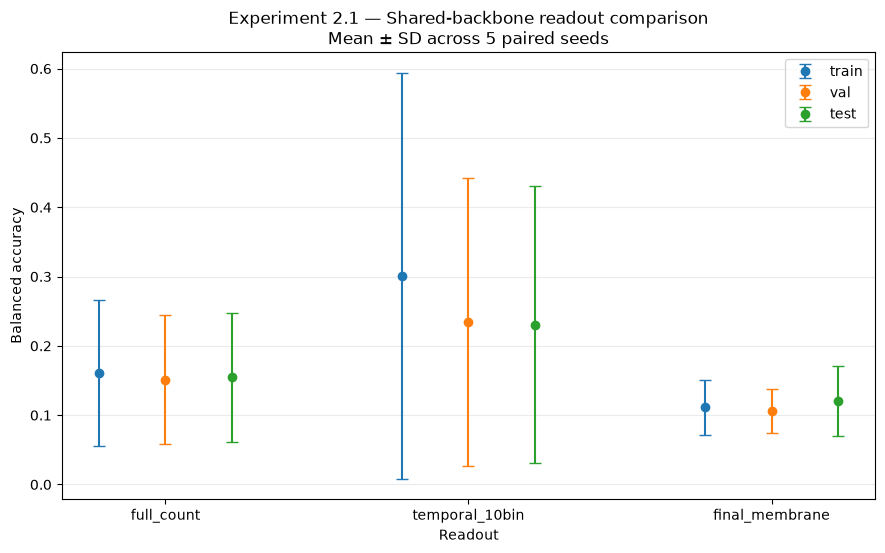

In [104]:
fig, ax = plt.subplots(
    figsize=(10.5, 5.8)
)

x = np.arange(
    len(READOUTS),
    dtype=float,
)

offsets = {
    "train": -0.22,
    "val": 0.0,
    "test": 0.22,
}

for split_name in (
    "train",
    "val",
    "test",
):
    means = []
    sds = []

    for readout in READOUTS:
        sdf = results[
            results.readout
            == readout
        ]

        means.append(
            sdf[
                f"{split_name}_balanced_accuracy"
            ].mean()
        )

        sds.append(
            sdf[
                f"{split_name}_balanced_accuracy"
            ].std(ddof=1)
        )

    ax.errorbar(
        x + offsets[split_name],
        means,
        yerr=sds,
        marker="o",
        capsize=4,
        linestyle="none",
        label=split_name,
    )

ax.set_xticks(
    x,
    READOUTS,
)
ax.set_ylabel(
    "Balanced accuracy"
)
ax.set_xlabel(
    "Readout"
)
ax.set_title(
    "Experiment 2.1 — Shared-backbone readout comparison\n"
    f"Mean ± SD across {len(SEEDS)} paired seeds"
)
ax.grid(
    True,
    axis="y",
    alpha=0.25,
)
ax.legend()
plt.show()


### 17.2 Seed-paired test balanced accuracy


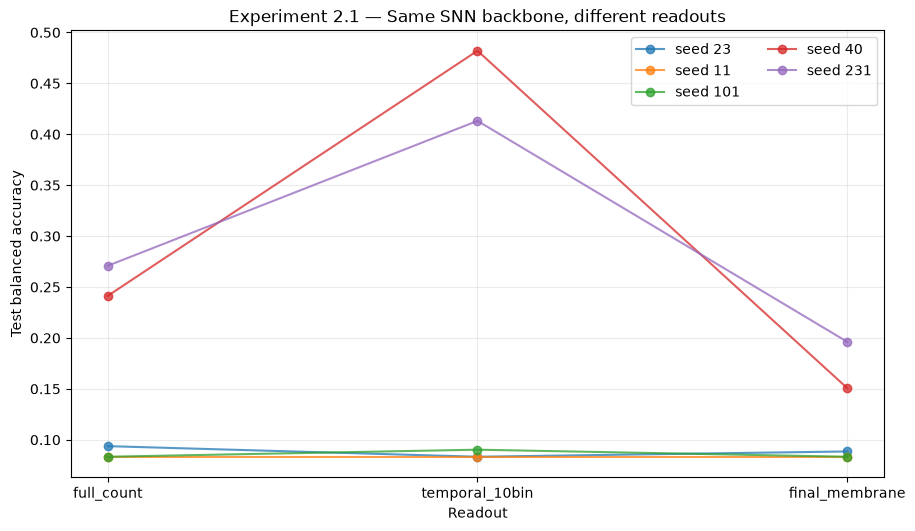

In [105]:
fig, ax = plt.subplots(
    figsize=(10.5, 5.8)
)

for seed in SEEDS:
    sdf = results[
        results.seed == seed
    ].copy()

    sdf["_order"] = (
        sdf["readout"]
        .map(order_map)
    )

    sdf = sdf.sort_values(
        "_order"
    )

    ax.plot(
        np.arange(
            len(sdf)
        ),
        sdf[
            "test_balanced_accuracy"
        ],
        marker="o",
        alpha=0.75,
        label=f"seed {seed}",
    )

ax.set_xticks(
    np.arange(
        len(READOUTS)
    ),
    READOUTS,
)
ax.set_ylabel(
    "Test balanced accuracy"
)
ax.set_xlabel(
    "Readout"
)
ax.set_title(
    "Experiment 2.1 — Same SNN backbone, different readouts"
)
ax.grid(
    True,
    alpha=0.25,
)
ax.legend(
    ncol=2
)
plt.show()


## 18. Shared-backbone firing diagnostics

These statistics are **not grouped by readout** anymore.

That is intentional: every readout sees the same frozen SNN activity.


,seed,split,l1_firing_rate,l2_firing_rate,output_firing_rate,network_firing_rate,silent_output_fraction,samples
0,23,train,0.000140,2.666840e-05,0.000009,0.000077,0.993538,619
1,23,val,0.000055,0.000000e+00,0.000000,0.000025,1.000000,125
2,23,test,0.000188,5.466578e-05,0.000083,0.000118,0.976048,167
3,11,train,0.000151,5.104868e-05,0.000063,0.000098,0.987076,619
4,11,val,0.000032,0.000000e+00,0.000000,0.000015,1.000000,125
5,11,test,0.000126,1.194683e-05,0.000004,0.000063,0.994012,167
6,101,train,0.000152,5.996445e-05,0.000194,0.000114,0.983845,619
7,101,val,0.000036,4.386950e-07,0.000000,0.000017,1.000000,125
8,101,test,0.000126,3.584048e-05,0.000073,0.000080,0.982036,167
9,40,train,0.007571,4.560265e-02,0.063577,0.029757,0.116317,619


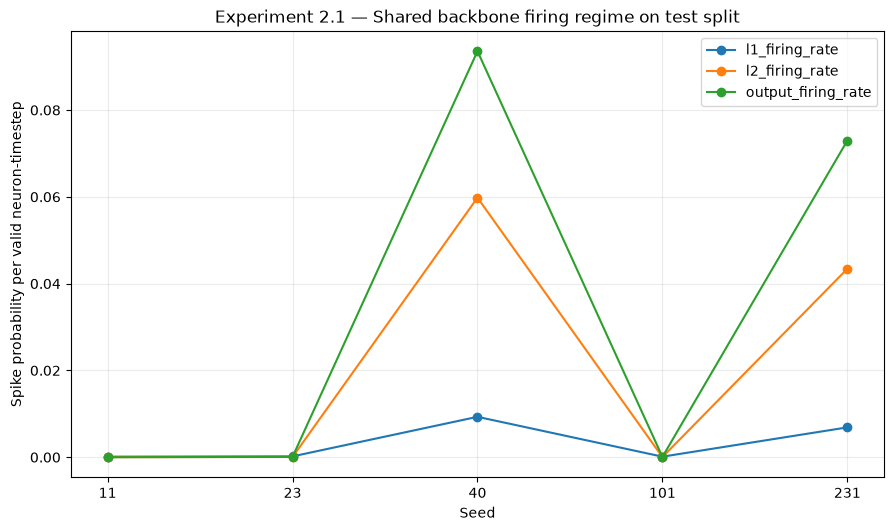

Zero-input diagnostic:


,seed,zero_l1_firing_rate,zero_l2_firing_rate,zero_output_firing_rate
0,23,0.0,0.0,0.0
1,11,0.0,0.0,0.0
2,101,0.0,0.0,0.0
3,40,0.0,0.0,0.0
4,231,0.0,0.0,0.0


In [106]:
display(
    activity_results
)

test_activity = (
    activity_results[
        activity_results.split
        == "test"
    ]
    .sort_values(
        "seed"
    )
)

fig, ax = plt.subplots(
    figsize=(10.5, 5.8)
)

for metric in (
    "l1_firing_rate",
    "l2_firing_rate",
    "output_firing_rate",
):
    ax.plot(
        test_activity[
            "seed"
        ].astype(str),
        test_activity[
            metric
        ],
        marker="o",
        label=metric,
    )

ax.set_ylabel(
    "Spike probability per valid neuron-timestep"
)
ax.set_xlabel(
    "Seed"
)
ax.set_title(
    "Experiment 2.1 — Shared backbone firing regime on test split"
)
ax.grid(
    True,
    alpha=0.25,
)
ax.legend()
plt.show()


print("Zero-input diagnostic:")
display(
    zero_input_results
)

if (
    test_activity[
        "output_firing_rate"
    ]
    > 0.5
).any():
    print(
        "WARNING: output firing rate exceeds 0.5 for at least one seed. "
        "Inspect saturation / tonic firing before interpreting readout results."
    )

if (
    zero_input_results[
        "zero_output_firing_rate"
    ]
    > 0.05
).any():
    print(
        "WARNING: zero input produces non-trivial output firing. "
        "Bias-driven tonic activity is a plausible cause."
    )


## 19. Backbone training curves


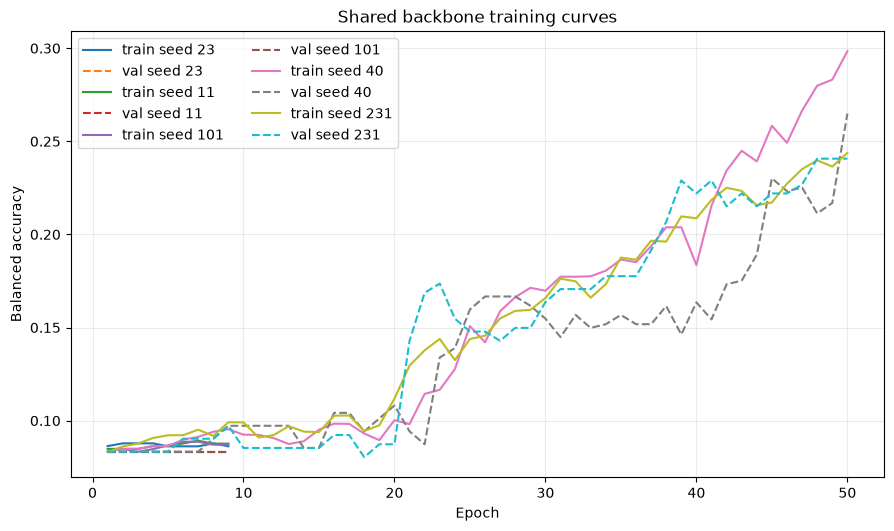

In [107]:
fig, ax = plt.subplots(
    figsize=(10.5, 5.8)
)

for seed in SEEDS:
    sdf = backbone_histories[
        backbone_histories.seed
        == seed
    ]

    ax.plot(
        sdf["epoch"],
        sdf[
            "train_balanced_accuracy"
        ],
        label=f"train seed {seed}",
    )

    ax.plot(
        sdf["epoch"],
        sdf[
            "val_balanced_accuracy"
        ],
        linestyle="--",
        label=f"val seed {seed}",
    )

ax.set_xlabel(
    "Epoch"
)
ax.set_ylabel(
    "Balanced accuracy"
)
ax.set_title(
    "Shared backbone training curves"
)
ax.grid(
    True,
    alpha=0.25,
)
ax.legend(
    ncol=2
)
plt.show()


## 20. Save provenance


In [108]:
provenance = {
    "experiment_id": EXPERIMENT_ID,
    "experiment_title": EXPERIMENT_TITLE,
    "dataset_roots": [
        str(Path(p).resolve())
        for p in DATASET_ROOTS
    ],
    "seeds": list(SEEDS),
    "split_seed": SPLIT_SEED,
    "included_labels": (
        None
        if INCLUDED_LABELS is None
        else list(
            map(
                str,
                INCLUDED_LABELS,
            )
        )
    ),
    "class_to_idx": CLASS_TO_IDX,
    "sampling_rate_hz": SAMPLING_RATE_HZ,
    "event_representation": EVENT_REPRESENTATION,
    "event_feature_schema": EVENT_FEATURE_SCHEMA,
    "encoder_spec_sha256": ENCODER_SPEC_SHA256,
    "input_channels": INPUT_CHANNELS,
    "hidden_width": HIDDEN_WIDTH,
    "readouts": list(READOUTS),
    "n_temporal_bins": N_TEMPORAL_BINS,
    "tau_syn_ms": TAU_SYN_MS,
    "tau_mem_ms": TAU_MEM_MS,
    "alpha": ALPHA,
    "beta": BETA,
    "threshold": THRESHOLD,
    "surrogate_slope": SURROGATE_SLOPE,
    "reset_mechanism": RESET_MECHANISM,
    "linear_bias": LINEAR_BIAS,
    "batch_size": BATCH_SIZE,
    "num_epochs": NUM_EPOCHS,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "spike_regularization": SPIKE_REGULARIZATION,
    "train_fraction": TRAIN_FRACTION,
    "val_fraction": VAL_FRACTION,
    "backbone_training_objective": (
        "masked per-valid-timestep cross entropy; "
        "repo-style Action0 objective"
    ),
    "backbone_training_count_per_seed": 1,
    "backbone_selection_metric": BACKBONE_SELECTION_METRIC,
    "readout_training": {
        "full_count": "none; direct frozen-backbone output spike count",
        "temporal_10bin": (
            "freeze backbone; train Linear(10K -> K) "
            "on frozen train features"
        ),
        "final_membrane": (
            "none; direct final-valid output membrane"
        ),
    },
    "temporal_head_epochs": TEMPORAL_HEAD_EPOCHS,
    "temporal_head_patience": TEMPORAL_HEAD_PATIENCE,
    "temporal_head_learning_rate": TEMPORAL_HEAD_LR,
    "temporal_head_weight_decay": TEMPORAL_HEAD_WEIGHT_DECAY,
    "primary_report_metric": "test balanced accuracy",
    "input_normalization": "none; direct weighted events preserved",
    "recurrence": False,
    "learn_alpha": LEARN_ALPHA,
    "learn_beta": LEARN_BETA,
    "learn_threshold": LEARN_THRESHOLD,
}

with open(
    RESULTS_DIR
    / "experiment_2_1_provenance.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        provenance,
        f,
        indent=2,
        ensure_ascii=False,
    )

print(
    "Saved artifacts to:",
    RESULTS_DIR,
)

for path in sorted(
    RESULTS_DIR.glob(
        "experiment_2_1_*"
    )
):
    print(
        " -",
        path.name,
    )


Saved artifacts to: /home/ted/project/writingring-viz/notebooks/artifacts/experiment_2_1_snn_readout_sanity_check_fixed
 - experiment_2_1_backbone_activity.csv
 - experiment_2_1_backbone_training_histories.csv
 - experiment_2_1_paired_deltas.csv
 - experiment_2_1_provenance.json
 - experiment_2_1_results.csv
 - experiment_2_1_summary.csv
 - experiment_2_1_temporal_head_histories.csv
 - experiment_2_1_zero_input_activity.csv


## Interpretation guide

This corrected notebook supports a much cleaner conclusion.

### If `temporal_10bin` clearly beats `full_count`

Because the SNN backbone is now identical, the result means:

\[
\boxed{\text{coarse temporal position in the SNN output contains useful class information that whole-sequence count discards}}
\]

There is still one caveat: the 10-bin readout has an extra trainable linear head. If the gain is large, a later parameter-control readout can quantify how much of the gain comes from temporal position versus added readout capacity.

### If `full_count` and `temporal_10bin` are close

Then the SNN has likely already converted the relevant temporal structure into class-selective total output activity. `full_count` is the simpler control for Experiment 2.2.

### If all three readouts are weak

First inspect the **shared backbone**, not the readouts:

- train BA;
- validation BA;
- L1/L2/output firing rates;
- zero-input firing;
- silent-output fraction.

Do not proceed to a width sweep if the backbone itself never learns.

### If output firing is extremely high

For example, output firing rate \(>0.5\), inspect:

- `LINEAR_BIAS=True`;
- fixed threshold;
- input amplitude scale;
- synaptic decay;
- possible tonic firing under zero input.

The zero-input diagnostic in this notebook is specifically intended to expose this failure mode.

### What Experiment 2.1 now holds fixed

Across readouts, within each seed:

- same user split;
- same trained SNN weights;
- same hidden states / output spike trajectories;
- same output membrane trajectories;
- same neuron dynamics.

Only the readout changes.


## Audit checklist

Before treating the result as evidence:

1. Confirm the intended combination roots are selected.
2. Confirm metadata says `event_representation == "unsigned"`.
3. Confirm `INPUT_CHANNELS` matches the new polarity-split representation.
4. Confirm actual valid event values are all non-negative.
5. Confirm train/val/test users are disjoint.
6. Confirm the backbone is trained exactly once per seed.
7. Confirm `full_count`, `temporal_10bin`, and `final_membrane` use features extracted from that same frozen backbone.
8. Confirm only the 10-bin linear head is trained after backbone freezing.
9. Confirm firing diagnostics are reported per seed/split, not per readout.
10. Inspect zero-input firing before interpreting very high output firing rates.
11. Inspect training curves; if train BA remains near chance, readout comparison is not yet meaningful.
12. Expand from two seeds to five seeds only after the training/firing regime is stable.
